In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score,mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression


In [58]:
df=pd.read_csv('Melbourne_housing.csv')
df.head()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4652\4116430136.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('Melbourne_housing.csv')


,Suburb,Address,Rooms,Type,Method,SellerG,Date,Distance,Postcode,Bedroom,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Latitude,Longtitude,Regionname,Propertycount,ParkingArea,Price
0,Abbotsford,68 Studley St,2,h,SS,Jellis,3/9/2016,2.5,3067.0,2.0,...,126.0,inf,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0,Carport,NaN
1,Airport West,154 Halsey Rd,3,t,PI,Nelson,3/9/2016,13.5,3042.0,3.0,...,303.0,225,2016.0,Moonee Valley City Council,-37.7180,144.8780,Western Metropolitan,3464.0,Detached Garage,840000.0
2,Albert Park,105 Kerferd Rd,2,h,S,hockingstuart,3/9/2016,3.3,3206.0,2.0,...,120.0,82,1900.0,Port Phillip City Council,-37.8459,144.9555,Southern Metropolitan,3280.0,Attached Garage,1275000.0
3,Albert Park,85 Richardson St,2,h,S,Thomson,3/9/2016,3.3,3206.0,2.0,...,159.0,inf,NaN,Port Phillip City Council,-37.8450,144.9538,Southern Metropolitan,3280.0,Indoor,1455000.0
4,Alphington,30 Austin St,3,h,SN,McGrath,3/9/2016,6.4,3078.0,3.0,...,174.0,122,2003.0,Darebin City Council,-37.7818,145.0198,Northern Metropolitan,2211.0,Parkade,NaN


In [59]:
df.shape

(34857, 22)

In [60]:
df.size

766854

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  object 
 1   Address        34857 non-null  object 
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  object 
 4   Method         34857 non-null  object 
 5   SellerG        34857 non-null  object 
 6   Date           34857 non-null  object 
 7   Distance       34856 non-null  float64
 8   Postcode       34856 non-null  float64
 9   Bedroom        26640 non-null  float64
 10  Bathroom       26631 non-null  float64
 11  Car            26129 non-null  float64
 12  Landsize       23047 non-null  float64
 13  BuildingArea   13760 non-null  object 
 14  YearBuilt      15551 non-null  float64
 15  CouncilArea    34854 non-null  object 
 16  Latitude       26881 non-null  float64
 17  Longtitude     26881 non-null  float64
 18  Region

In [62]:
df.describe()

,Rooms,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,YearBuilt,Latitude,Longtitude,Propertycount,Price
count,34857.000000,34856.000000,34856.000000,26640.000000,26631.000000,26129.000000,23047.000000,15551.000000,26881.000000,26881.000000,34854.000000,2.724700e+04
mean,3.031012,11.184929,3116.062859,3.084647,1.624798,1.728845,593.598993,1965.289885,-37.810634,145.001851,7572.888306,1.050173e+06
std,0.969933,6.788892,109.023903,0.980690,0.724212,1.010771,3398.841946,37.328178,0.090279,0.120169,4428.090313,6.414671e+05
min,1.000000,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.190430,144.423790,83.000000,8.500000e+04
25%,2.000000,6.400000,3051.000000,2.000000,1.000000,1.000000,224.000000,1940.000000,-37.862950,144.933500,4385.000000,6.350000e+05
50%,3.000000,10.300000,3103.000000,3.000000,2.000000,2.000000,521.000000,1970.000000,-37.807600,145.007800,6763.000000,8.700000e+05
75%,4.000000,14.000000,3156.000000,4.000000,2.000000,2.000000,670.000000,2000.000000,-37.754100,145.071900,10412.000000,1.295000e+06
max,16.000000,48.100000,3978.000000,30.000000,12.000000,26.000000,433014.000000,2106.000000,-37.390200,145.526350,21650.000000,1.120000e+07


In [63]:
df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Method', 'SellerG', 'Date',
       'Distance', 'Postcode', 'Bedroom', 'Bathroom', 'Car', 'Landsize',
       'BuildingArea', 'YearBuilt', 'CouncilArea', 'Latitude', 'Longtitude',
       'Regionname', 'Propertycount', 'ParkingArea', 'Price'],
      dtype='object')

In [64]:
df.isnull().sum()

Suburb               0
Address              0
Rooms                0
Type                 0
Method               0
SellerG              0
Date                 0
Distance             1
Postcode             1
Bedroom           8217
Bathroom          8226
Car               8728
Landsize         11810
BuildingArea     21097
YearBuilt        19306
CouncilArea          3
Latitude          7976
Longtitude        7976
Regionname           0
Propertycount        3
ParkingArea          0
Price             7610
dtype: int64

In [65]:
missingpercent=(df.isnull().sum()/len(df) )*100
print(missingpercent)

Suburb            0.000000
Address           0.000000
Rooms             0.000000
Type              0.000000
Method            0.000000
SellerG           0.000000
Date              0.000000
Distance          0.002869
Postcode          0.002869
Bedroom          23.573457
Bathroom         23.599277
Car              25.039447
Landsize         33.881286
BuildingArea     60.524428
YearBuilt        55.386293
CouncilArea       0.008607
Latitude         22.882061
Longtitude       22.882061
Regionname        0.000000
Propertycount     0.008607
ParkingArea       0.000000
Price            21.832057
dtype: float64


In [66]:
categories=df.select_dtypes(include='object')
numeric=df.select_dtypes(include='number')
print(numeric)

       Rooms  Distance  Postcode  Bedroom  Bathroom  Car  Landsize  YearBuilt  \
0          2       2.5    3067.0      2.0       1.0  1.0     126.0        NaN   
1          3      13.5    3042.0      3.0       2.0  1.0     303.0     2016.0   
2          2       3.3    3206.0      2.0       1.0  0.0     120.0     1900.0   
3          2       3.3    3206.0      2.0       1.0  0.0     159.0        NaN   
4          3       6.4    3078.0      3.0       2.0  1.0     174.0     2003.0   
...      ...       ...       ...      ...       ...  ...       ...        ...   
34852      3      12.0    3073.0      3.0       1.0  1.0       NaN     1990.0   
34853      4      20.6    3064.0      4.0       2.0  2.0       NaN     1995.0   
34854      4      22.2    3172.0      4.0       2.0  2.0     534.0     1970.0   
34855      3      22.2    3172.0      3.0       2.0  1.0     544.0        NaN   
34856      4      16.5    3049.0      4.0       2.0  6.0     813.0     1960.0   

       Latitude  Longtitude

## EDA(Exploratory data anlaysis)

### for numeric variables

In [67]:
null=df.isna().sum()
print(type(null))
null=null.to_frame()
print(type(null))
print(null)



<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>
                   0
Suburb             0
Address            0
Rooms              0
Type               0
Method             0
SellerG            0
Date               0
Distance           1
Postcode           1
Bedroom         8217
Bathroom        8226
Car             8728
Landsize       11810
BuildingArea   21097
YearBuilt      19306
CouncilArea        3
Latitude        7976
Longtitude      7976
Regionname         0
Propertycount      3
ParkingArea        0
Price           7610


Text(0.5, 1.0, 'heat map of null values')

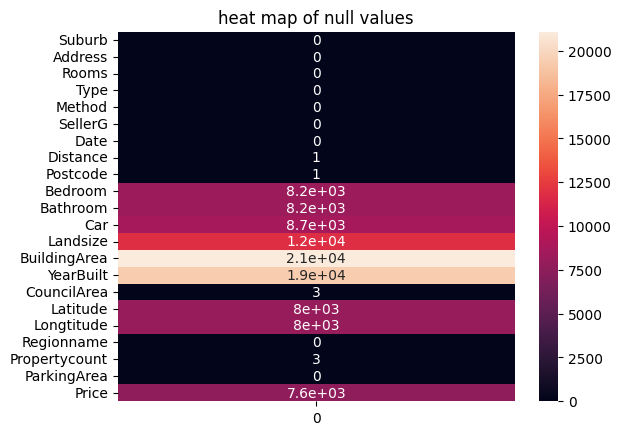

In [30]:
sns.heatmap(null,annot=True)
plt.title('heat map of null values')

In [31]:
print(numeric.shape[1])

12


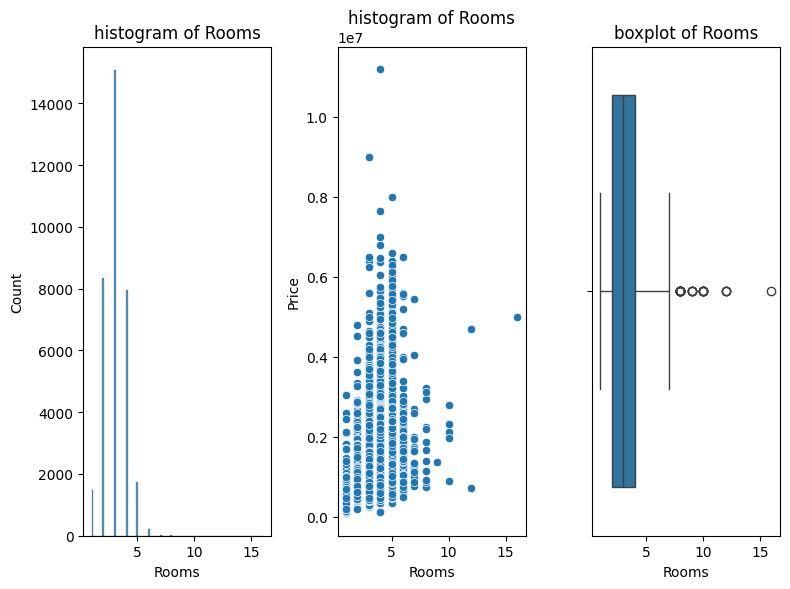

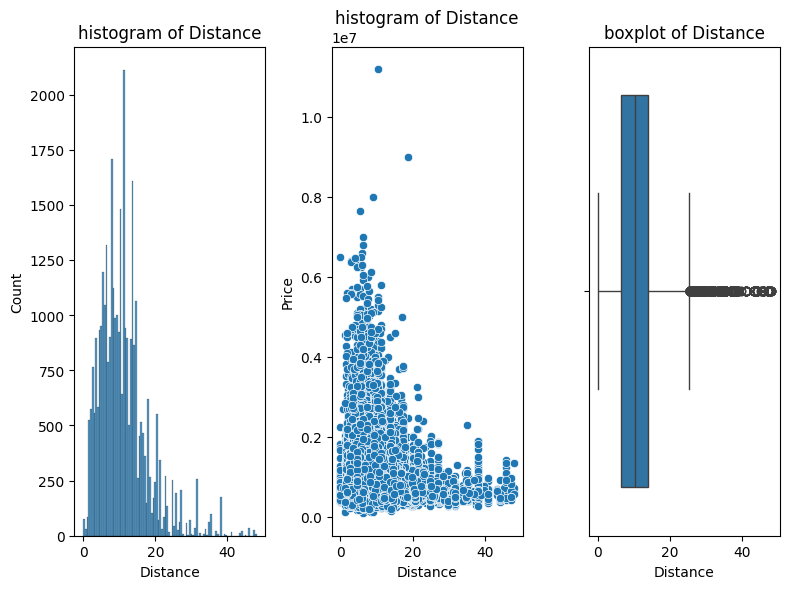

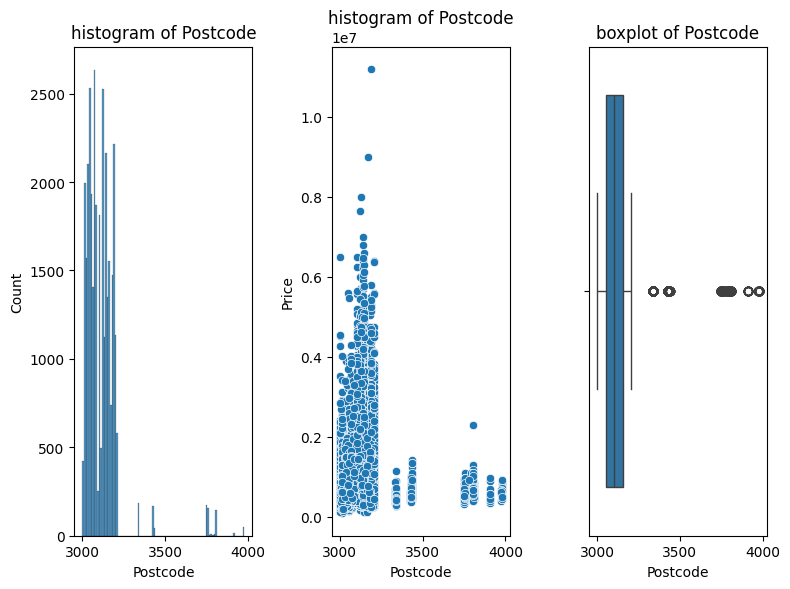

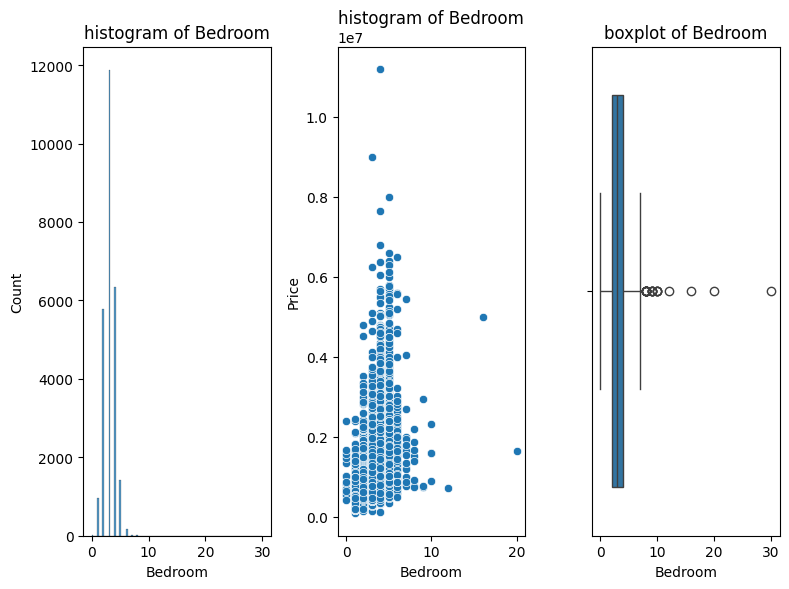

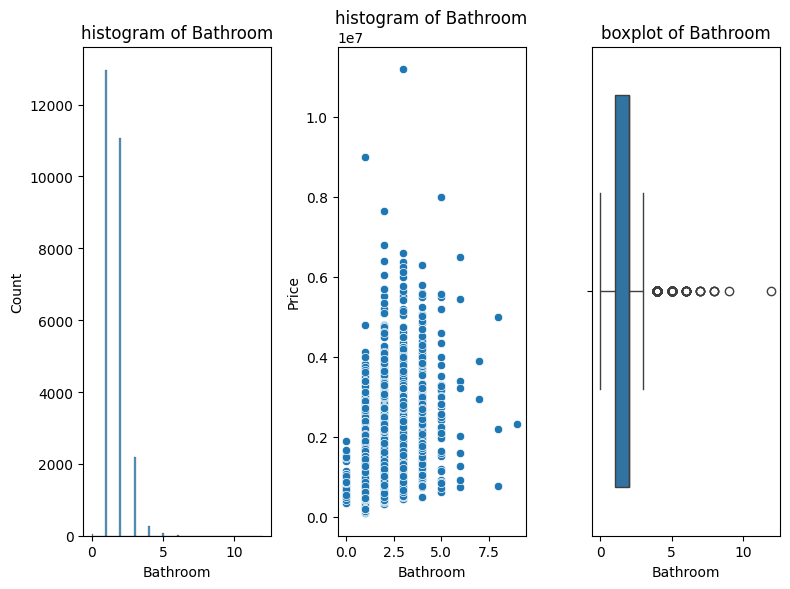

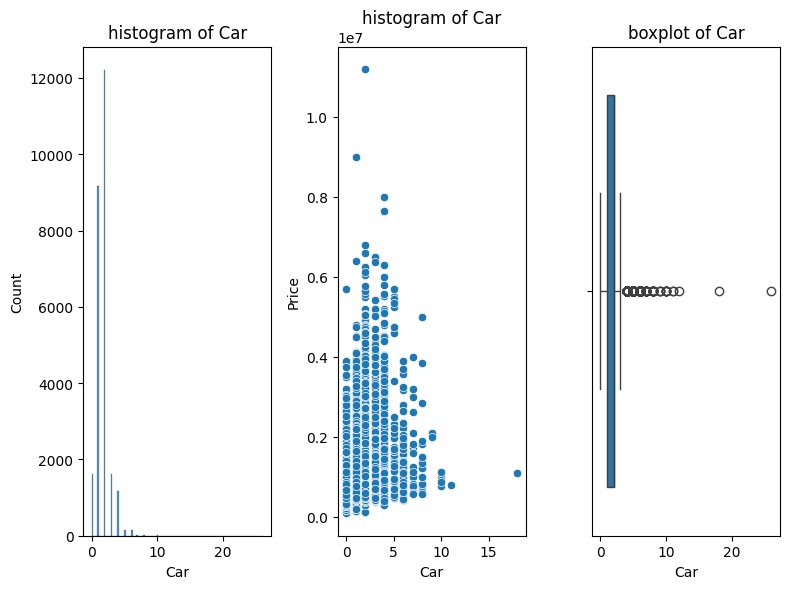

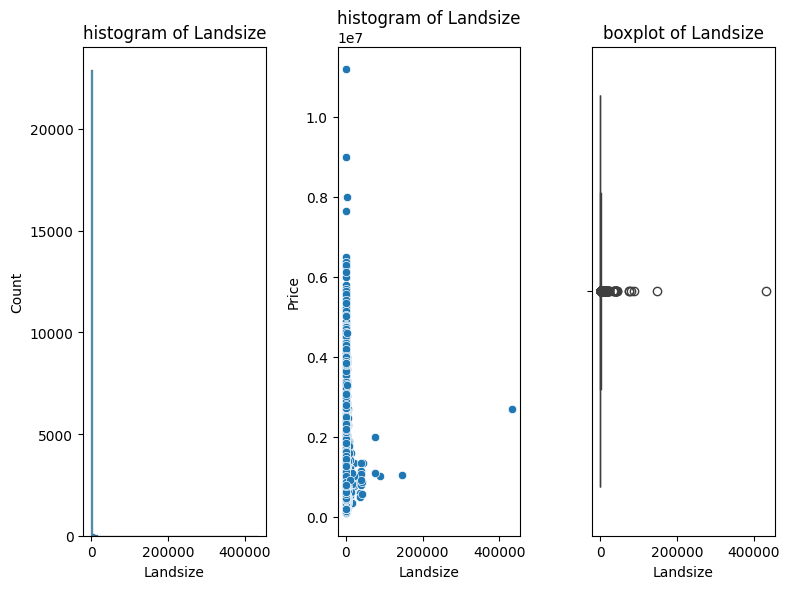

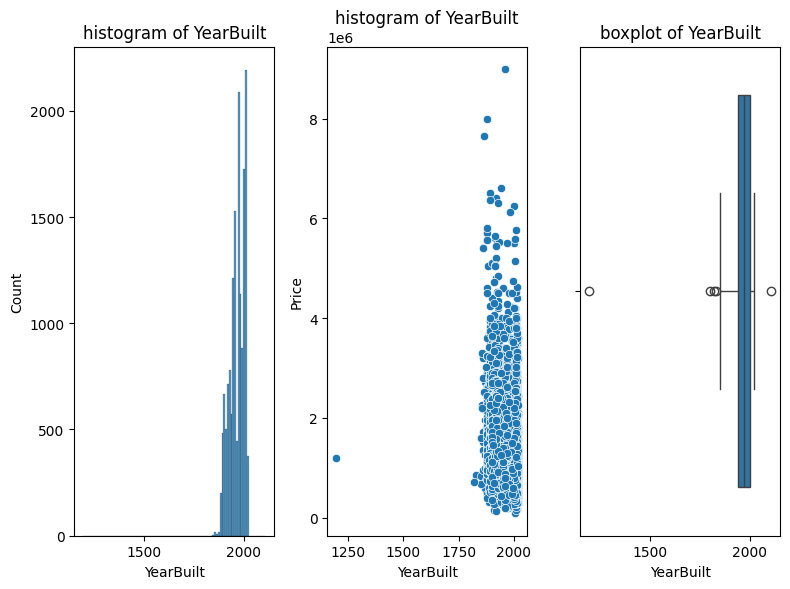

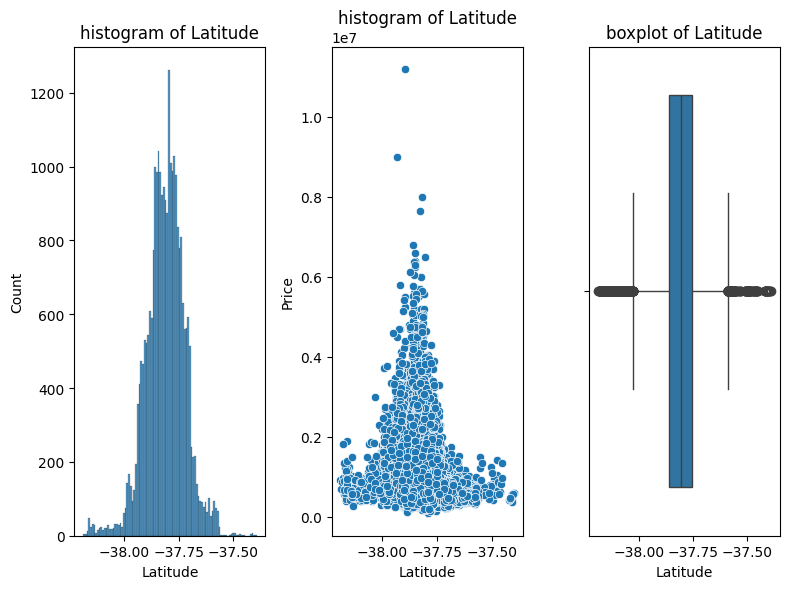

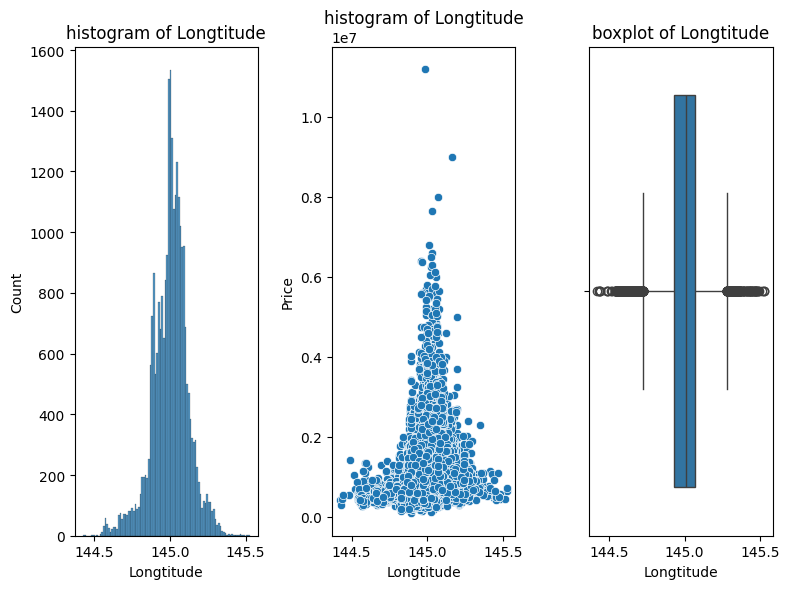

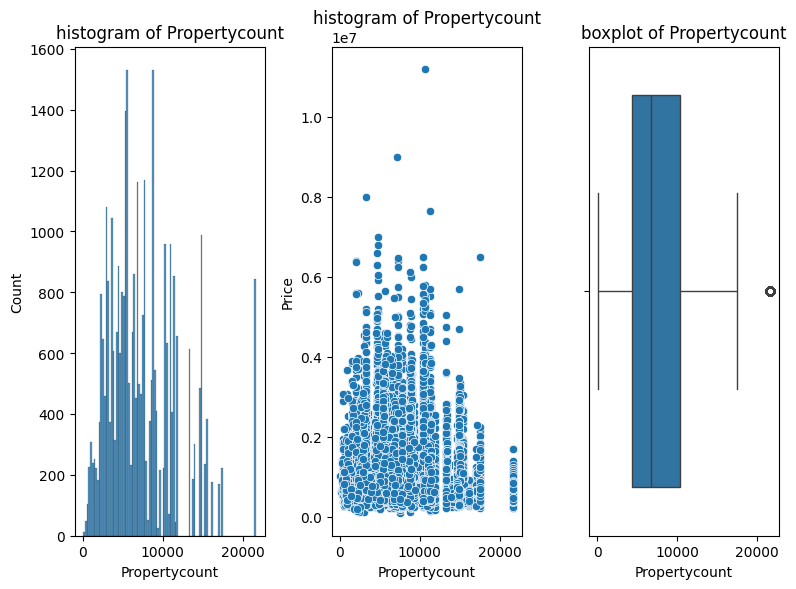

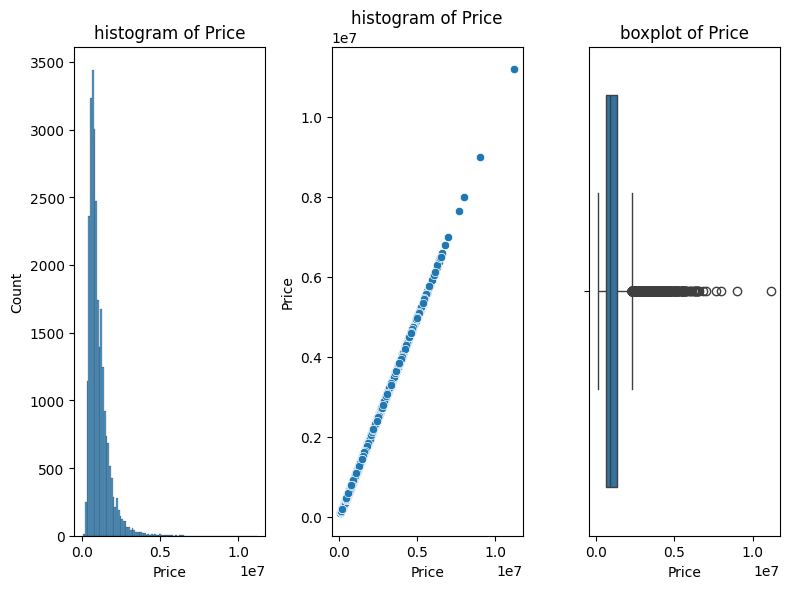

In [28]:
for varaible in numeric:
    plt.figure(figsize=(8,6))
    plt.subplot(1,3,1)
    sns.histplot(data=df,x=varaible,bins=100)
    plt.title(f"histogram of {varaible}")
    
    plt.subplot(1,3,2)
    sns.scatterplot(data=df,x=varaible,y=df['Price'])
    plt.title(f"histogram of {varaible}")
    
    plt.subplot(1,3,3)
    sns.boxplot(data=df,x=varaible)
    plt.title(f"boxplot of {varaible}")
    
    plt.tight_layout()
    plt.show()

In [29]:
for variable in categories:
    print(f"the unique present in {variable}",df[variable].nunique())

the unique present in Suburb 351
the unique present in Address 34009
the unique present in Type 3
the unique present in Method 9
the unique present in SellerG 388
the unique present in Date 78
the unique present in BuildingArea 994
the unique present in CouncilArea 33
the unique present in Regionname 8
the unique present in ParkingArea 8


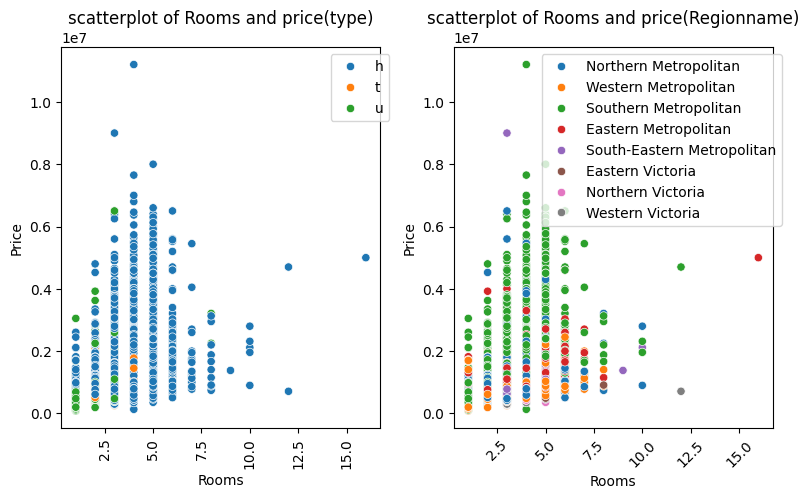

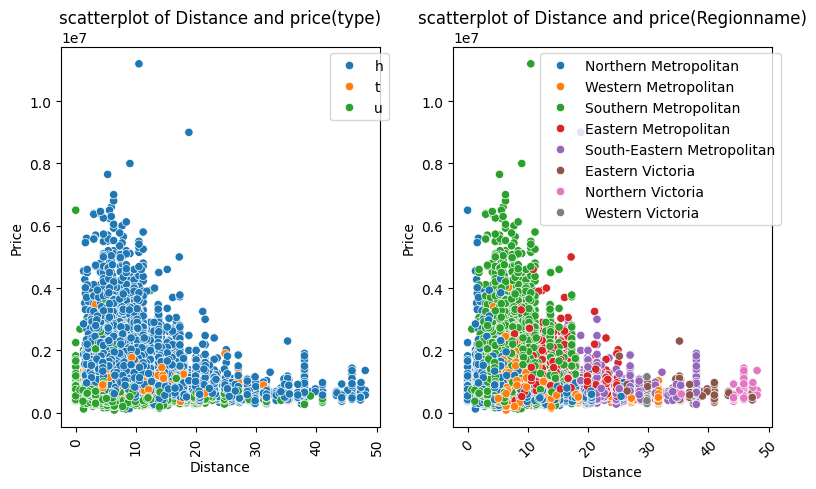

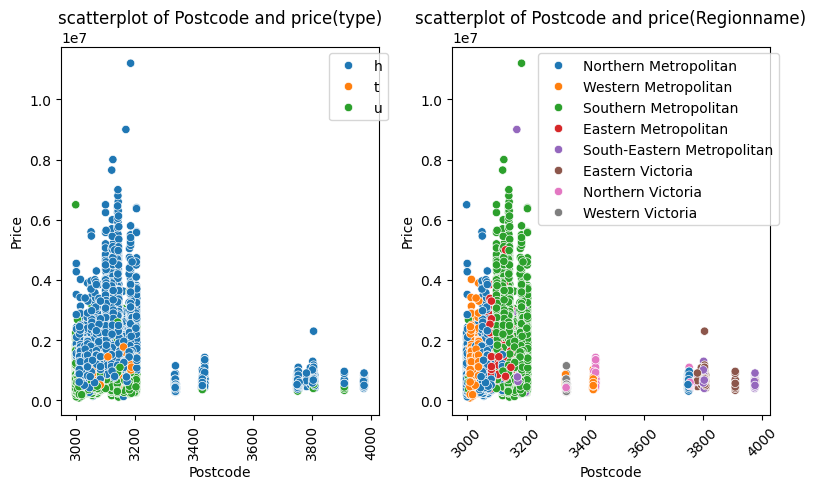

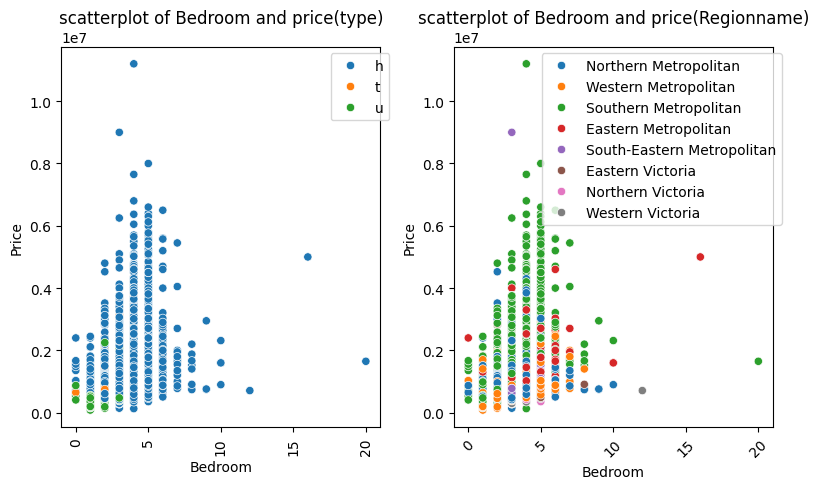

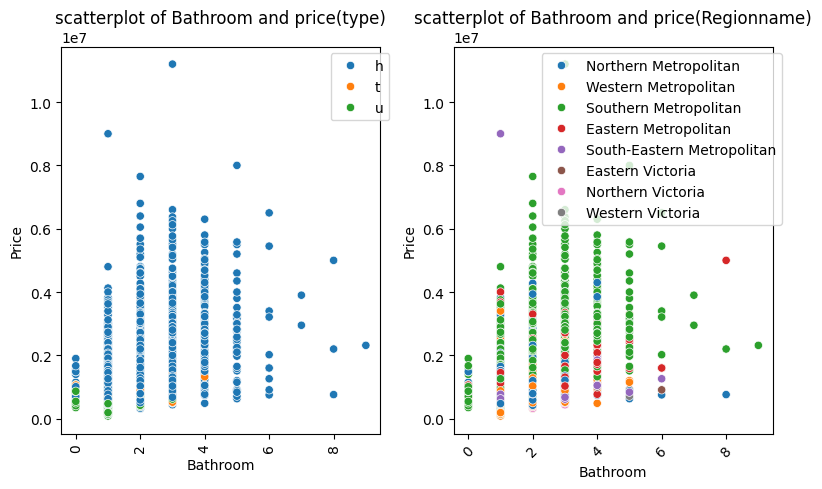

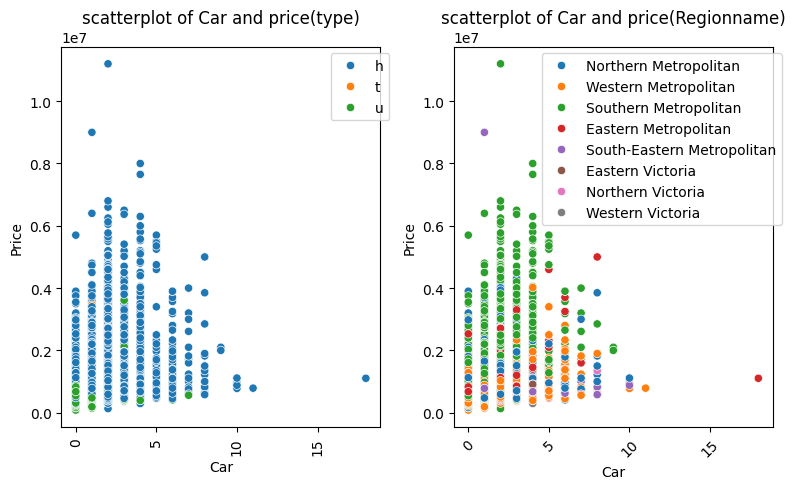

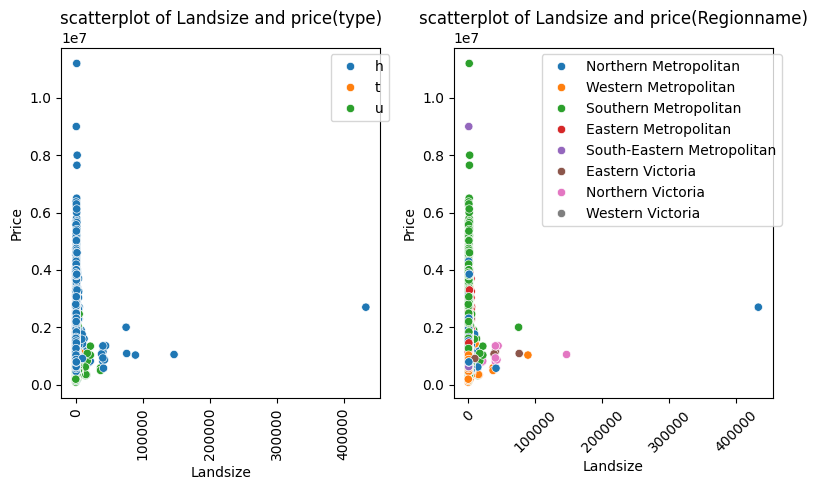

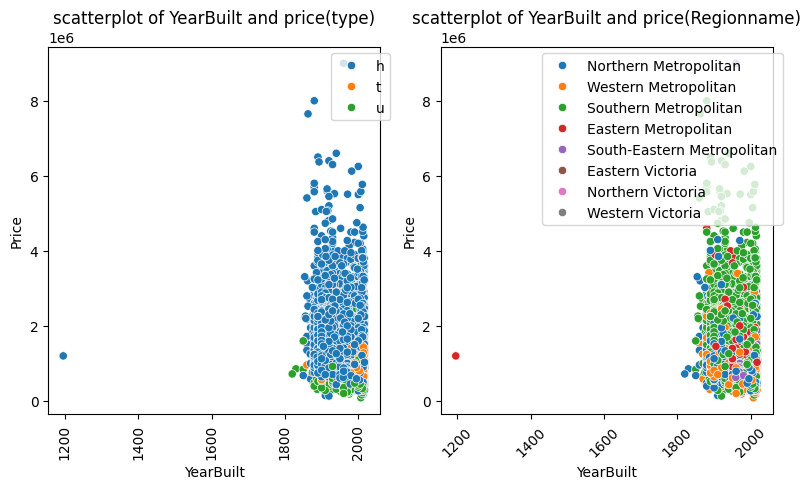

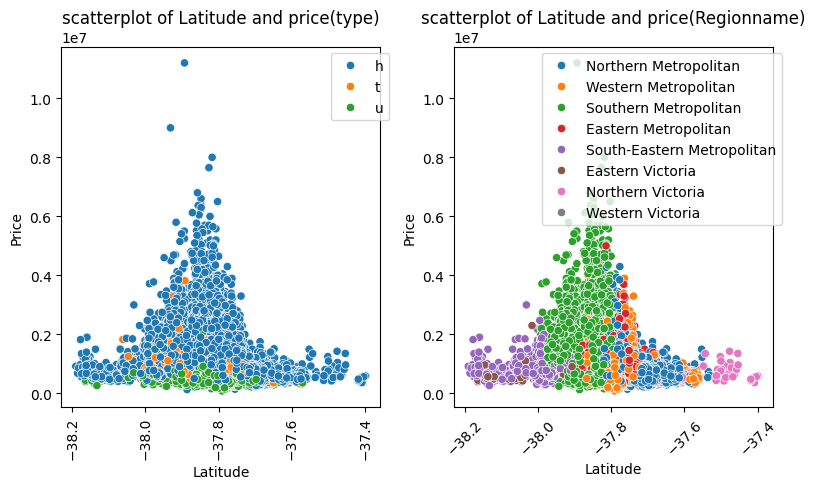

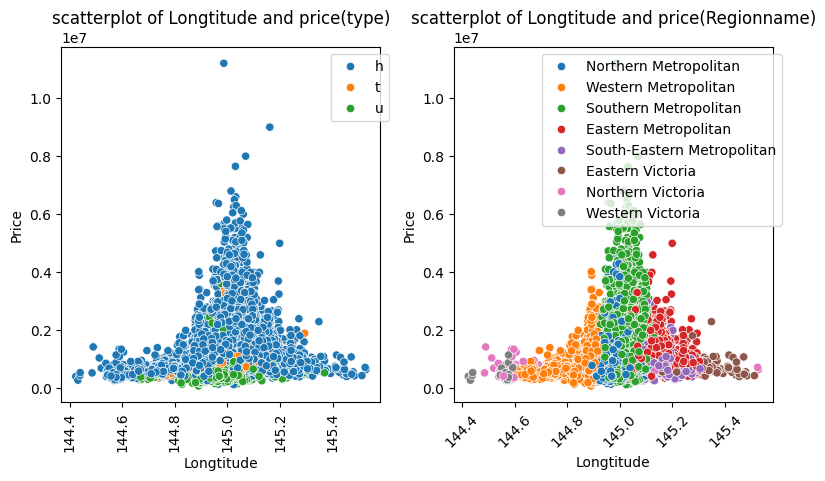

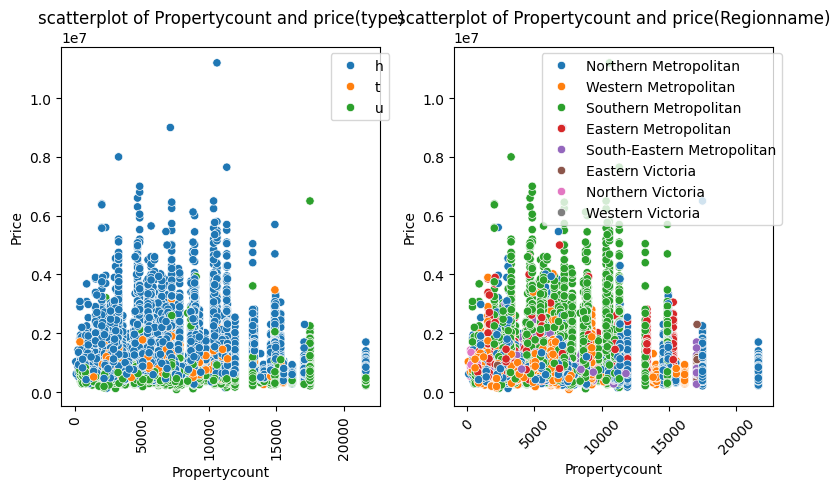

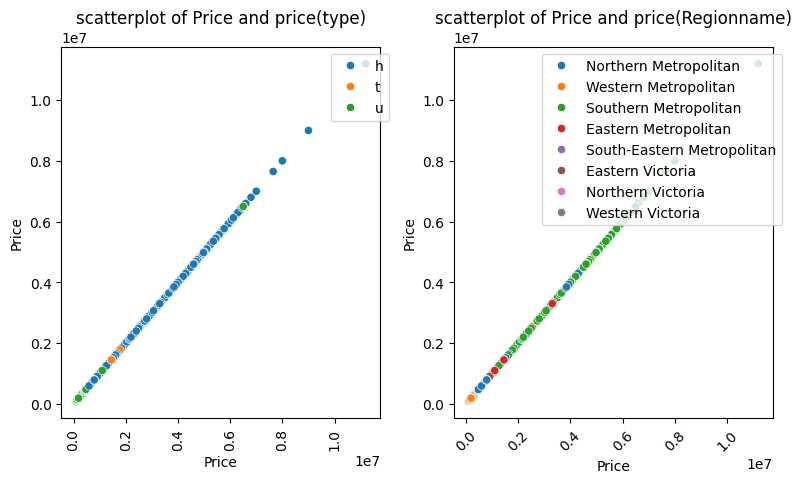

In [33]:
for varaible in numeric:
    plt.figure(figsize=(8,5))
    plt.subplot(1,2,1)
    sns.scatterplot(data=df,x=varaible,y=df['Price'],hue=df['Type'])
    plt.title(f'scatterplot of {varaible} and price(type)')
    plt.xticks(rotation=90)
    plt.legend(loc='upper right',bbox_to_anchor=(1.05,1))
    
    plt.subplot(1,2,2)
    sns.scatterplot(data=df,x=varaible,y=df["Price"],hue=df['Regionname'])
    plt.title(f'scatterplot of {varaible} and price(Regionname)')
    plt.xticks(rotation=45)
    plt.legend(loc='upper right',bbox_to_anchor=(1.05,1))
    plt.tight_layout()
    plt.show()

### for categories

In [34]:
for variable in categories:
    print(f"the unique present in {variable}",df[variable].nunique())

the unique present in Suburb 351
the unique present in Address 34009
the unique present in Type 3
the unique present in Method 9
the unique present in SellerG 388
the unique present in Date 78
the unique present in BuildingArea 994
the unique present in CouncilArea 33
the unique present in Regionname 8
the unique present in ParkingArea 8


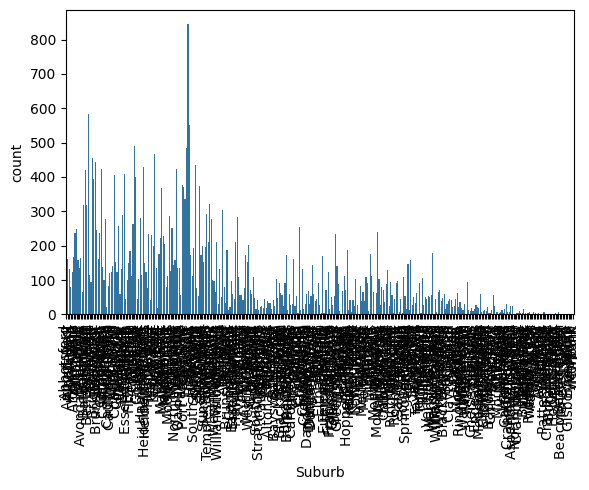

no operation for address


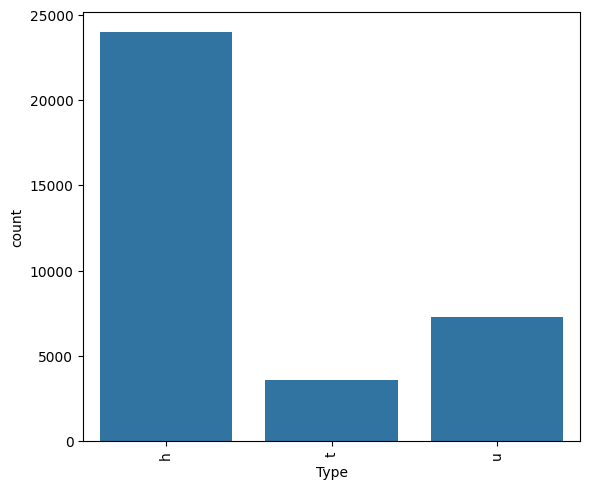

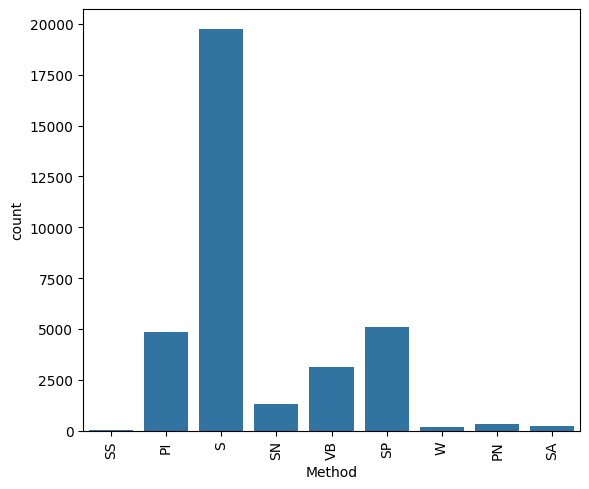

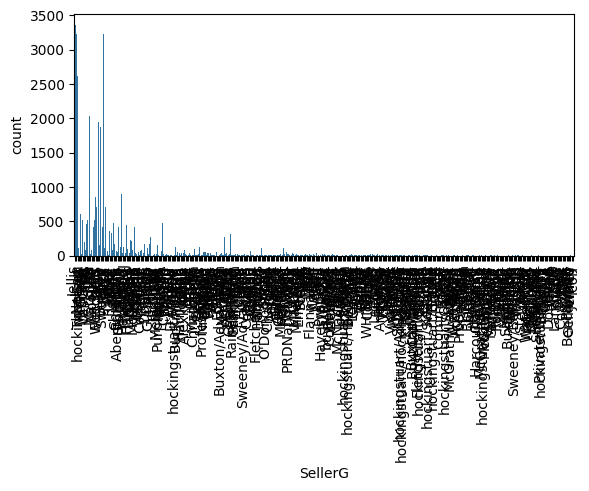

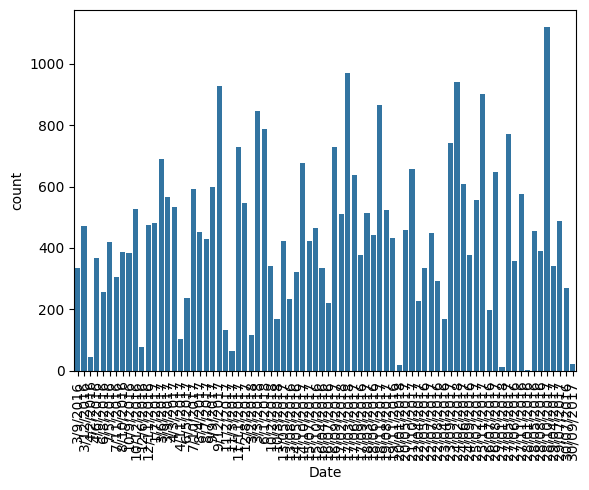

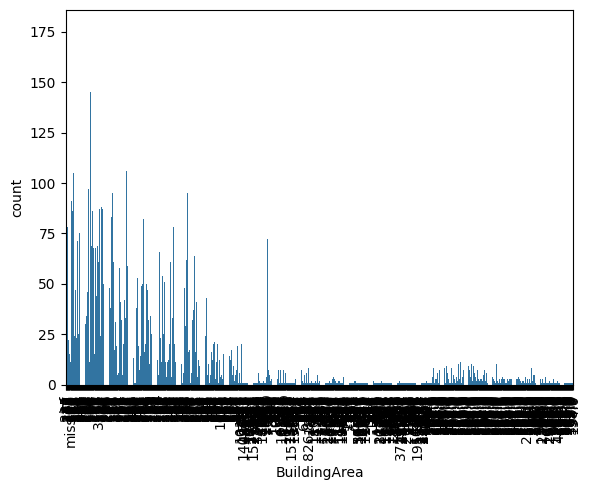

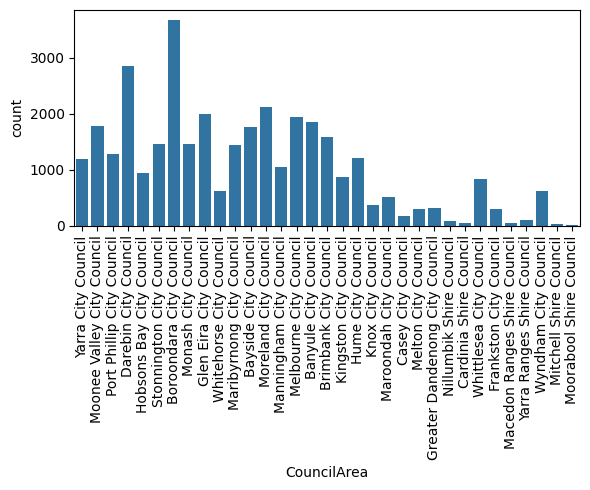

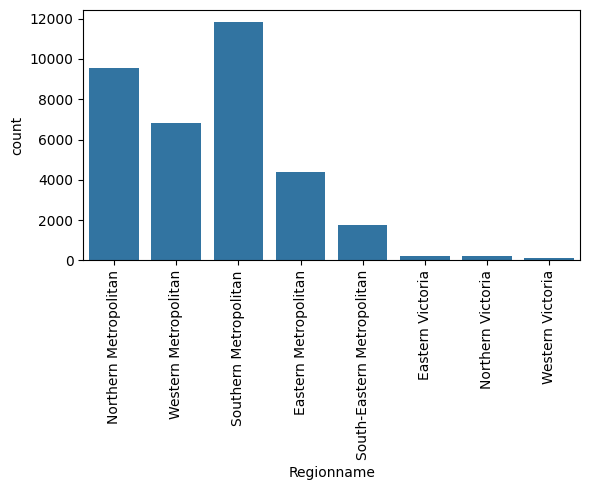

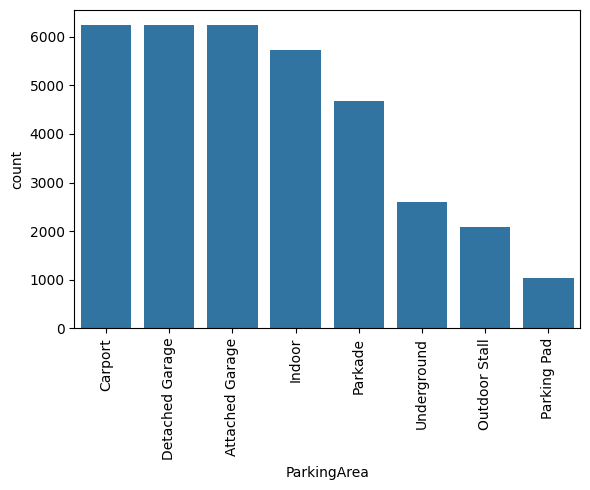

In [35]:
for variable in categories:
    if variable =='Address':
        print("no operation for address")
    else:
        plt.figure(figsize=(6,5))
        sns.countplot(data=df,x=variable)
        plt.xticks(rotation=90)
    
        plt.tight_layout()
        plt.show()

### Model Building
1. linear model
2. random forest

In [68]:
missingpercent=(df.isnull().sum()/len(df) )*100
print(missingpercent)

Suburb            0.000000
Address           0.000000
Rooms             0.000000
Type              0.000000
Method            0.000000
SellerG           0.000000
Date              0.000000
Distance          0.002869
Postcode          0.002869
Bedroom          23.573457
Bathroom         23.599277
Car              25.039447
Landsize         33.881286
BuildingArea     60.524428
YearBuilt        55.386293
CouncilArea       0.008607
Latitude         22.882061
Longtitude       22.882061
Regionname        0.000000
Propertycount     0.008607
ParkingArea       0.000000
Price            21.832057
dtype: float64


SInce YearBUilt,BuildingArea have more than 50% missing data we will remove these column

In [69]:
df.drop(columns=['BuildingArea','YearBuilt','Address'],inplace=True)

In [70]:
df=df.dropna(subset=(["Price"]))

In [71]:
y=df['Price']
x=df.drop('Price',axis=1)

In [72]:
#split the data
trainx,testx,trainy,testy = train_test_split(x,y,test_size=0.2,random_state=10)


In [73]:
print(numeric.columns)
print(categories.columns)

Index(['Rooms', 'Distance', 'Postcode', 'Bedroom', 'Bathroom', 'Car',
       'Landsize', 'YearBuilt', 'Latitude', 'Longtitude', 'Propertycount',
       'Price'],
      dtype='object')
Index(['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date',
       'BuildingArea', 'CouncilArea', 'Regionname', 'ParkingArea'],
      dtype='object')


In [74]:
numerical=numeric.drop(columns=['Price','YearBuilt'],axis=1)
categories=categories.drop(columns=['BuildingArea','Address'],axis=1)

In [75]:
#pipeline for numeical data
num=Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy='median'))
    ]
)

In [76]:
cat=Pipeline(
    steps=[
        ("impute",SimpleImputer(strategy='most_frequent')),
        ('encode',OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [77]:
preprocessing=ColumnTransformer([
    ('number',num,numerical.columns.tolist()),
    ('cat',cat,categories.columns.tolist())
])

### Regression

In [78]:
pipeline1= Pipeline(
    steps=[
        ('transform',preprocessing),
        ('model',LinearRegression())
    ]
)

In [91]:
pipeline1.fit(trainx,trainy)

Pipeline(steps=[('transform',
                 ColumnTransformer(transformers=[('number',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Rooms', 'Distance',
                                                   'Postcode', 'Bedroom',
                                                   'Bathroom', 'Car',
                                                   'Landsize', 'Latitude',
                                                   'Longtitude',
                                                   'Propertycount']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Suburb', 'Type', 'Method',
                                                   'SellerG', 'Date',
                                                   'CouncilArea', 'Regionname',
                                                   'ParkingArea'])])),
                ('model', LinearRegression())])

In [92]:
ypred=pipeline1.predict(testx)

In [93]:
r2_reg=r2_score(testy,ypred)
print(r2_reg)
mae_reg=mean_absolute_error(testy,ypred)
print(mae_reg)

0.6909646536072264
232340.54304833757


### Random forest

In [94]:
pipeline2=Pipeline(
    steps=[
    ('transform',preprocessing),
    ('model',RandomForestRegressor(
         n_estimators=150,
       max_depth=15,
       min_samples_split=5,
       random_state=10
    ))
]
)

In [95]:
pipeline2.fit(trainx,trainy)

Pipeline(steps=[('transform',
                 ColumnTransformer(transformers=[('number',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Rooms', 'Distance',
                                                   'Postcode', 'Bedroom',
                                                   'Bathroom', 'Car',
                                                   'Landsize', 'Latitude',
                                                   'Longtitude',
                                                   'Propertycount']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Suburb', 'Type', 'Method',
                                                   'SellerG', 'Date',
                                                   'CouncilArea', 'Regionname',
                                                   'ParkingArea'])])),
                ('model',
                 RandomForestRegressor(max_depth=15, min_samples_split=5,
                                       n_estimators=150, random_state=10))])

In [96]:
ypred2=pipeline2.predict(testx)

In [97]:
r2_rand=r2_score(testy,ypred2)
print(r2_rand)
mae_rand=mean_absolute_error(testy,ypred2)
print(mae_rand)

0.7940639411367688
171525.4034015502


### comparision

In [100]:
print(f"the r2_score for linear model is {r2_reg} and for random forest is {r2_rand}")
print(f"the mean absolute error for linear model is {mae_reg} and for random forest is {mae_rand}")

the r2_score for linear model is 0.6909646536072264 and for random forest is 0.7940639411367688
the mean absolute error for linear model is 232340.54304833757 and for random forest is 171525.4034015502


 So since r2 score of random forest is more it explains the result much better compared to Linear regreeion. And MAE for random forest is way lower than that of linear model.